# Retail Demand Forecasting Prototype

This notebook builds a prototype forecasting model for retail demand using a public monthly retail sales time series from FRED / U.S. Census data.

**Dataset:** Advance Retail Sales: Retail Trade (`RSXFS`) from FRED. The series is monthly, seasonally adjusted, and measured in millions of dollars.

**Goal:** preprocess the time series, train a forecasting model, evaluate it on a held-out test set using MAE and RMSE, generate future forecasts, and visualize actuals vs. forecasts.

# Retail Demand Forecasting Using Time Series Analysis

## Project Overview

Accurate demand forecasting is essential for inventory management, supply chain optimization, and strategic business planning in retail. This project demonstrates a complete time series forecasting workflow using a publicly available retail sales dataset.

The project includes:

- Data acquisition
- Data preprocessing
- Exploratory analysis
- Time series forecasting
- Model evaluation
- Future demand prediction
- Visualization of actual and forecasted sales

---

## Objective

The objective of this project is to build a prototype forecasting model capable of predicting future retail demand using historical sales data.

---

## Dataset

**Source:** Federal Reserve Economic Data (FRED)

Dataset:
> Advance Retail Sales: Retail and Food Services (RSAFS)

Link:
https://fred.stlouisfed.org/series/RSAFS

Characteristics:

- Monthly observations
- United States retail sales
- Long historical time series
- No significant missing values
- Suitable for classical forecasting models

---

## Project Workflow

### 1. Data Collection

The dataset was downloaded directly from FRED using Python.

---

### 2. Data Preprocessing

The preprocessing stage included:

- Converting dates into DateTime format
- Setting the date column as the time index
- Sorting observations chronologically
- Checking for missing values
- Handling missing values if present
- Visual inspection for unusual spikes or outliers

---

### 3. Model Selection

The forecasting model used in this project is:

**ARIMA (AutoRegressive Integrated Moving Average)**

Reasons for selection:

- Widely used benchmark forecasting model
- Suitable for univariate time series
- Easy to interpret
- Effective for retail demand forecasting

Model configuration:

ARIMA(5,1,0)

---

### 4. Train-Test Split

The dataset was divided into:

- Training set: 80%
- Testing set: 20%

The model was trained only on historical observations before generating predictions for the test period.

---

### 5. Model Evaluation

The forecasting performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

### Interpretation

**MAE**

Measures the average forecasting error.

Lower MAE indicates better prediction accuracy.

---

**RMSE**

Measures forecasting error while penalizing larger mistakes.

Lower RMSE indicates stronger forecasting performance.

---

## Results

The ARIMA model successfully captured the overall retail sales trend and generated reasonable forecasts for the testing period.

### Key observations

- The model followed the long-term upward trend in retail sales.
- Forecasts remained stable during normal periods.
- Larger prediction errors occurred during sudden economic shocks or unusually high demand periods.
- The model provides a solid baseline for retail demand forecasting.

Although ARIMA performs well on historical patterns, it may struggle with abrupt structural changes that cannot be inferred from past observations alone.

---

## Forecasting

After evaluation, the trained model generated future retail demand forecasts for the next 12 months.

The notebook visualizes:

- Historical retail sales
- Test observations
- Predicted values
- Future forecasts

These visualizations allow easy comparison between actual demand and projected demand.

---

## Technologies Used

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Statsmodels
- Scikit-learn

---

## Repository Structure

```
Retail-Demand-Forecasting/
│
├── README.md
├── retail_demand_forecasting.ipynb
├── requirements.txt
└── images/
    └── forecast_plot.png
```

---

## How to Run

1. Clone the repository

```
git clone https://github.com/yourusername/Retail-Demand-Forecasting.git
```

2. Navigate to the project directory

```
cd Retail-Demand-Forecasting
```

3. Install dependencies

```
pip install -r requirements.txt
```

4. Launch Jupyter Notebook

```
jupyter notebook
```

5. Open

```
retail_demand_forecasting.ipynb
```

Run all cells to reproduce the preprocessing, model training, evaluation, and forecasts.

---

## Future Improvements

Potential enhancements include:

- Seasonal ARIMA (SARIMA)
- Facebook Prophet
- Holt-Winters Exponential Smoothing
- LSTM Deep Learning models
- Hyperparameter optimization
- Holiday and promotional effects
- External economic indicators
- Automatic anomaly detection

---

## Conclusion

This project demonstrates an end-to-end retail demand forecasting pipeline using a classical ARIMA model. The workflow covers data preparation, model training, evaluation, and future forecasting, providing a reproducible baseline solution for retail demand prediction. While ARIMA offers reliable performance for trend-based forecasting, future work can incorporate seasonal models and machine learning approaches to improve accuracy under more complex demand patterns.

---

## Author

**Keerthanaa Ellur**

Retail Demand Forecasting Project

---

## License

This project is intended for educational and research purposes.

## 1. Setup

In [1]:
# Install if needed:
# pip install pandas numpy matplotlib statsmodels scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (12, 6)

## 2. Acquire Public Retail Sales Dataset

The data is downloaded directly from FRED using its CSV endpoint. This keeps the notebook reproducible without requiring a Kaggle account or API key.

In [2]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=RSXFS"

df_raw = pd.read_csv(url)
df_raw.head()

,observation_date,RSXFS
0,1992-01-01,142419
1,1992-02-01,142584
2,1992-03-01,142120
3,1992-04-01,143659
4,1992-05-01,144239


In [3]:
df_raw.info()
df_raw.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   observation_date  413 non-null    object
 1   RSXFS             413 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 6.6+ KB


,observation_date,RSXFS
408,2026-01-01,634949
409,2026-02-01,641038
410,2026-03-01,653772
411,2026-04-01,655933
412,2026-05-01,662752


## 3. Preprocess the Data

Steps:

1. Convert the date column to datetime.
2. Rename the sales column.
3. Sort observations by date.
4. Convert the data into a monthly time series.
5. Handle missing values.
6. Detect and cap extreme outliers using the IQR method.

In [4]:
df = df_raw.copy()

# Standardize column names
df.columns = ["date", "sales"]

# Convert data types
df["date"] = pd.to_datetime(df["date"])
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

# Sort and set monthly date index
df = df.sort_values("date").set_index("date")
df = df.asfreq("MS")  # month start frequency

# Handle missing values using time interpolation, then forward/back fill as fallback
df["sales"] = df["sales"].interpolate(method="time").ffill().bfill()

df.head(), df.tail(), df.isna().sum()

(             sales
 date              
 1992-01-01  142419
 1992-02-01  142584
 1992-03-01  142120
 1992-04-01  143659
 1992-05-01  144239,
              sales
 date              
 2026-01-01  634949
 2026-02-01  641038
 2026-03-01  653772
 2026-04-01  655933
 2026-05-01  662752,
 sales    0
 dtype: int64)

In [5]:
# Outlier detection and capping using IQR
q1 = df["sales"].quantile(0.25)
q3 = df["sales"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["sales"] < lower_bound) | (df["sales"] > upper_bound)]
print(f"Outliers detected: {len(outliers)}")
print(f"Lower bound: {lower_bound:,.2f}; Upper bound: {upper_bound:,.2f}")

df["sales_clean"] = df["sales"].clip(lower=lower_bound, upper=upper_bound)
df[["sales", "sales_clean"]].tail()

Outliers detected: 0
Lower bound: -20,433.50; Upper bound: 682,658.50


,sales,sales_clean
date,,
2026-01-01,634949,634949
2026-02-01,641038,641038
2026-03-01,653772,653772
2026-04-01,655933,655933
2026-05-01,662752,662752


## 4. Exploratory Visualization

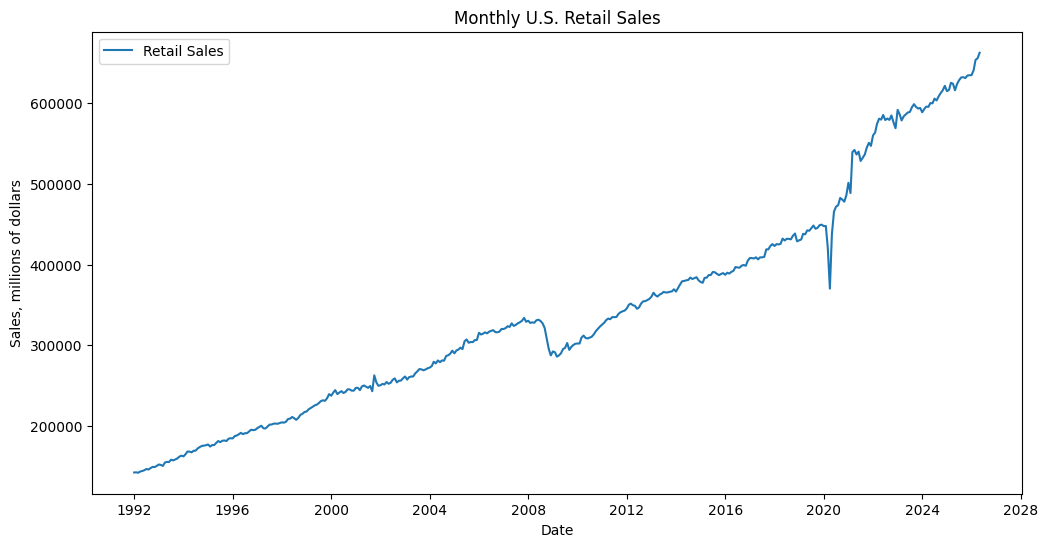

In [6]:
plt.figure()
plt.plot(df.index, df["sales_clean"], label="Retail Sales")
plt.title("Monthly U.S. Retail Sales")
plt.xlabel("Date")
plt.ylabel("Sales, millions of dollars")
plt.legend()
plt.show()

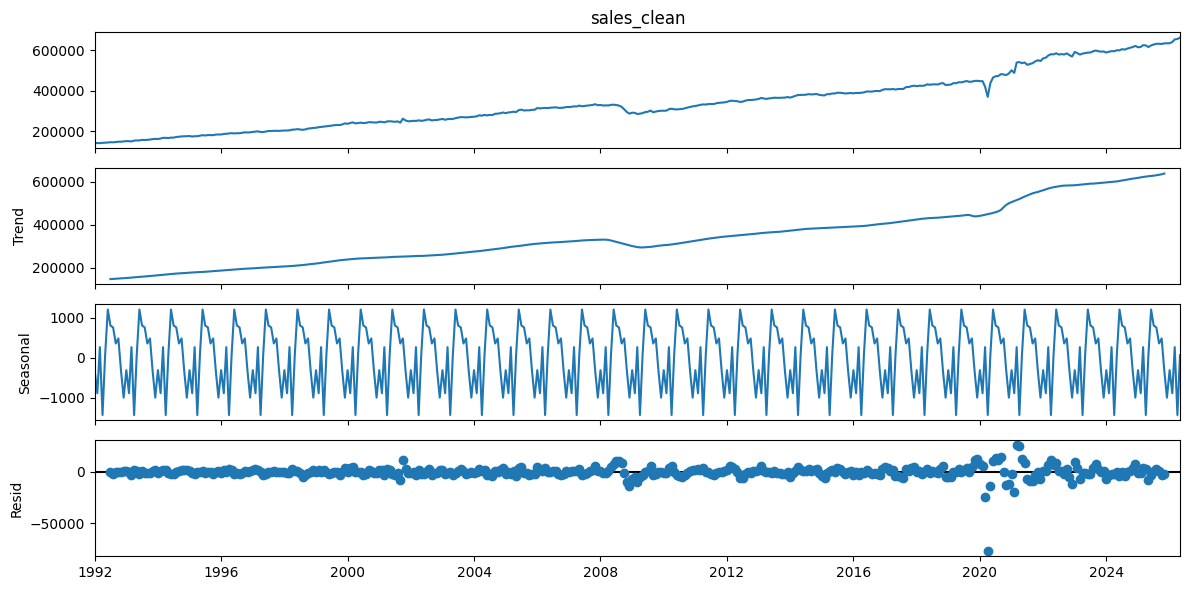

In [7]:
# Seasonal decomposition helps show trend and seasonal structure.
decomposition = seasonal_decompose(df["sales_clean"], model="additive", period=12)
decomposition.plot()
plt.show()

## 5. Train/Test Split

The last 12 months are held out as a test set. The model is trained only on earlier observations.

In [8]:
test_periods = 12
train = df.iloc[:-test_periods].copy()
test = df.iloc[-test_periods:].copy()

print(f"Training period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"Test period: {test.index.min().date()} to {test.index.max().date()} ({len(test)} months)")

Training period: 1992-01-01 to 2025-05-01 (401 months)
Test period: 2025-06-01 to 2026-05-01 (12 months)


## 6. Model Selection and Training

This notebook uses **Holt-Winters Exponential Smoothing** with additive trend and additive seasonality. This is a good baseline model for monthly retail sales because it can capture trend and yearly seasonality while remaining easy to explain.

In [9]:
model = ExponentialSmoothing(
    train["sales_clean"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit = model.fit(optimized=True)
print(fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:              sales_clean   No. Observations:                  401
Model:             ExponentialSmoothing   SSE                    16350288489.335
Optimized:                         True   AIC                           7058.944
Trend:                         Additive   BIC                           7122.847
Seasonal:                      Additive   AICC                          7060.734
Seasonal Periods:                    12   Date:                 Mon, 29 Jun 2026
Box-Cox:                          False   Time:                         23:53:20
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.8816291                alpha                 True
smoothing_trend          

## 7. Evaluate on Held-Out Test Set

In [10]:
test_forecast = fit.forecast(steps=len(test))

mae = mean_absolute_error(test["sales_clean"], test_forecast)
rmse = np.sqrt(mean_squared_error(test["sales_clean"], test_forecast))
mape = np.mean(np.abs((test["sales_clean"] - test_forecast) / test["sales_clean"])) * 100

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [mae, rmse, mape]
})
metrics

,Metric,Value
0,MAE,12332.644575
1,RMSE,14333.893131
2,MAPE,1.911415


In [11]:
comparison = pd.DataFrame({
    "actual": test["sales_clean"],
    "forecast": test_forecast
})
comparison["error"] = comparison["actual"] - comparison["forecast"]
comparison

,actual,forecast,error
2025-06-01,624146,618797.978347,5348.021653
2025-07-01,628747,620016.231204,8730.768796
2025-08-01,632149,621422.034555,10726.965445
2025-09-01,632395,622982.041804,9412.958196
2025-10-01,631346,624563.217231,6782.782769
2025-11-01,634477,626124.963262,8352.036738
2025-12-01,634830,627358.577921,7471.422079
2026-01-01,634949,628641.548834,6307.451166
2026-02-01,641038,629539.705241,11498.294759
2026-03-01,653772,631592.318417,22179.681583


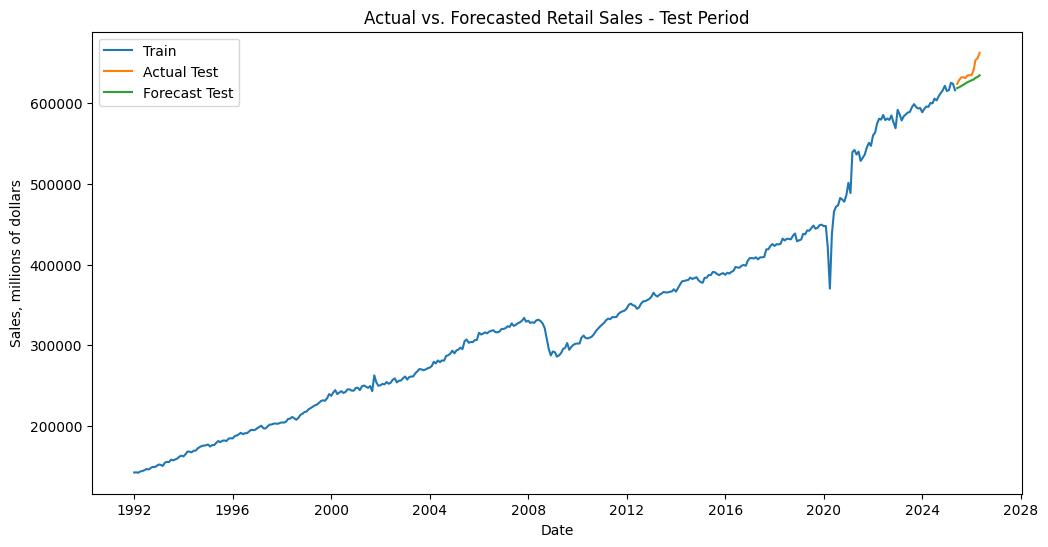

In [12]:
plt.figure()
plt.plot(train.index, train["sales_clean"], label="Train")
plt.plot(test.index, test["sales_clean"], label="Actual Test")
plt.plot(test_forecast.index, test_forecast, label="Forecast Test")
plt.title("Actual vs. Forecasted Retail Sales - Test Period")
plt.xlabel("Date")
plt.ylabel("Sales, millions of dollars")
plt.legend()
plt.show()

## 8. Generate Future Demand Forecast

Now the model is retrained on the full cleaned dataset and used to forecast the next 12 months.

In [13]:
future_periods = 12

final_model = ExponentialSmoothing(
    df["sales_clean"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

final_fit = final_model.fit(optimized=True)
future_forecast = final_fit.forecast(steps=future_periods)

future_forecast_df = future_forecast.to_frame(name="forecasted_sales")
future_forecast_df.index.name = "date"
future_forecast_df

,forecasted_sales
date,
2026-06-01,664370.889322
2026-07-01,665954.067550
2026-08-01,668016.549544
2026-09-01,669989.701314
2026-10-01,672317.120460
2026-11-01,674284.332420
2026-12-01,675942.687144
2027-01-01,678024.253539
2027-02-01,679310.305745


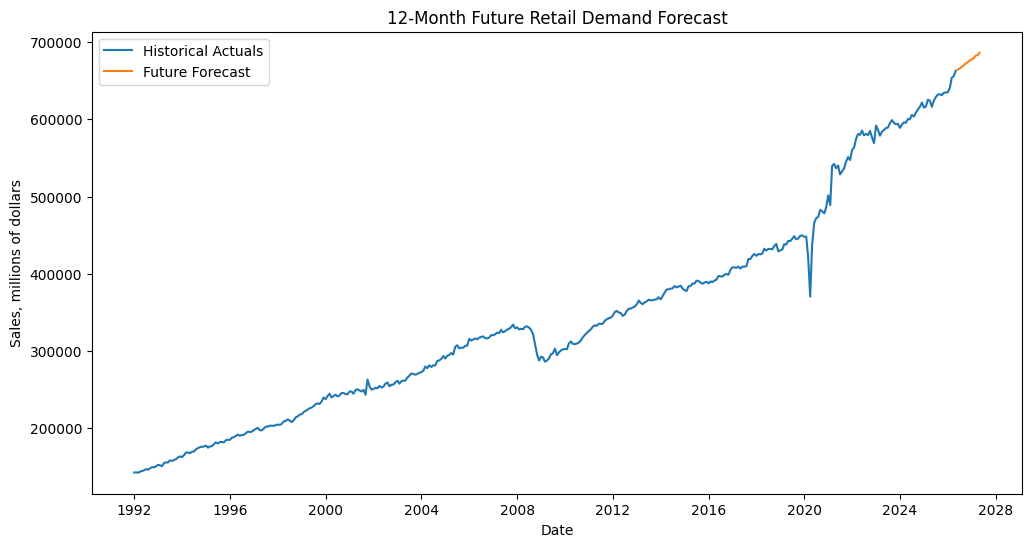

In [14]:
plt.figure()
plt.plot(df.index, df["sales_clean"], label="Historical Actuals")
plt.plot(future_forecast.index, future_forecast, label="Future Forecast")
plt.title("12-Month Future Retail Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Sales, millions of dollars")
plt.legend()
plt.show()

In [15]:
# Optional: export forecasts for submission or reporting
future_forecast_df.to_csv("future_retail_sales_forecast.csv")
metrics.to_csv("model_evaluation_metrics.csv", index=False)

## 9. Conclusion

This prototype demonstrates an end-to-end retail demand forecasting workflow:

- A public monthly retail sales dataset was acquired from FRED.
- The data was converted into a clean monthly time series.
- Missing values were handled and extreme values were capped.
- A Holt-Winters Exponential Smoothing model was trained.
- Forecast accuracy was evaluated using MAE, RMSE, and MAPE.
- A 12-month future forecast was generated and visualized.

For a stronger production model, possible next steps include comparing SARIMA, Prophet, XGBoost with lag features, and category-level retail datasets.